# TCC — Etapa 1: Baseline de detecção de ataques em redes IoT (CICIoT2023)

**Reprodução adaptada** de um notebook de referência de classificação binária
(Normal vs. Attack) sobre o CICIoT2023.

Este notebook **não é uma reprodução exata** do trabalho de referência. Ele
reaproveita a estrutura geral (carregamento dos CSVs, seleção de
características com `SelectKBest`/Mutual Information, comparação de modelos
clássicos), mas introduz alterações metodológicas deliberadas, documentadas na
seção "Divergências em relação ao notebook de referência".

## Objetivo desta etapa
Estabelecer um baseline **metodologicamente correto e reprodutível** do
desempenho de três modelos tradicionais de ML — Decision Tree, Random Forest e
Linear SVC — na classificação binária de tráfego IoT. A Etapa 2 do TCC
(robustez adversarial) será construída sobre os artefatos salvos ao final
deste notebook.



## 0. Configuração e parâmetros do experimento

Todos os parâmetros que afetam os resultados ficam concentrados aqui, para que
a metodologia do TCC possa citá-los diretamente.

In [28]:
# ---------- Dependências ----------
# Em ambiente Kaggle/Colab, instale as dependências antes de executar:
#   pip install -q kagglehub scikit-learn pandas numpy matplotlib seaborn joblib
%pip install seaborn
%pip install scikit-learn joblib
import os
import gc
import glob
import json
import time
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)

# =====================================================================
# PARÂMETROS DO EXPERIMENTO  (documentar estes valores na metodologia)
# =====================================================================
RANDOM_STATE = 42

# Amostragem: 20% de cada um dos 169 CSVs, para viabilidade computacional.
SAMPLE_FRAC = 0.20

# Proporção do conjunto de teste (isolado até a avaliação final).
TEST_SIZE = 0.20

# Seleção de características (SelectKBest + Mutual Information).
TOP_K_FEATURES = 20

# Subamostra usada APENAS para estimar a Mutual Information.
# Valores menores evitam que o estimador baseado em vizinhos esgote a RAM.
MI_SUBSAMPLE = 20_000

# Validação cruzada (apenas sobre o treino).
CV_FOLDS = 5
N_JOBS = -1
RUN_GRID_SEARCH = True
# Subamostra estratificada do TREINO usada na CV, para manter o custo viável.
CV_SUBSAMPLE = 300_000

# O treinamento final usa todo o conjunto de treino resultante da amostra de 20%.
# O teste permanece isolado e completo.
MODEL_TRAIN_SUBSAMPLE = None

# Tratamento de duplicatas — decidido ANTES do split (ver seção 3.5).
#   "drop"  : remove repetições exatas (features + rótulo), mantendo a 1ª ocorrência
#   "keep"  : mantém tudo (apenas diagnostica)
DUPLICATE_POLICY = "drop"

# Tratamento de registros com features idênticas e rótulos divergentes:
#   "keep"  : mantidos (ruído irredutível, reportado na metodologia)
#   "drop"  : removidos todos os registros envolvidos no conflito
CONFLICT_POLICY = "keep"

# Valores de k avaliados na análise de sensibilidade da seleção (seção 11).
K_GRID = [10, 20, 30, 40]

# Executar o apêndice com KNN (custoso — desligado por padrão).
RUN_KNN_APPENDIX = False

# Diretório de saída dos artefatos da Etapa 1.
ARTIFACTS_DIR = Path("artifacts_baseline")
ARTIFACTS_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_STATE)

ENV_INFO = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "cpu_count": os.cpu_count(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "sample_frac": SAMPLE_FRAC,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "top_k_features": TOP_K_FEATURES,
    "mi_subsample": MI_SUBSAMPLE,
    "cv_folds": CV_FOLDS,
    "n_jobs": N_JOBS,
    "run_grid_search": RUN_GRID_SEARCH,
    "cv_subsample": CV_SUBSAMPLE,
    "model_train_subsample": MODEL_TRAIN_SUBSAMPLE,
    "duplicate_policy": DUPLICATE_POLICY,
    "conflict_policy": CONFLICT_POLICY,
}
print(json.dumps(ENV_INFO, indent=2))

T0_GLOBAL = time.time()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
{
  "python": "3.14.4",
  "platform": "Windows-11-10.0.26200-SP0",
  "cpu_count": 12,
  "numpy": "2.4.4",
  "pandas": "3.0.3",
  "scikit-learn": "1.9.1",
  "sample_frac": 0.2,
  "random_state": 42,
  "test_size": 0.2,
  "top_k_features": 20,
  "mi_subsample": 20000,
  "cv_folds": 5,
  "n_jobs": -1,
  "run_grid_search": true,
  "cv_subsample": 300000,
  "model_train_subsample": null,
  "duplicate_policy": "drop",
  "conflict_policy": "keep"
}


## 1. Carregamento do dataset

O CICIoT2023 é distribuído em 169 arquivos CSV, que são partições de um mesmo
conjunto de capturas. Carrega-se uma amostra aleatória de `SAMPLE_FRAC` de
cada arquivo, preservando a proporção de contribuição de cada partição.

In [29]:
# ---------- Download via kagglehub ----------
try:
    import kagglehub
    DATA_DIR = kagglehub.dataset_download("akashdogra/cic-iot-2023")
except Exception as e:
    print("kagglehub indisponível:", e)
    # Ajuste manualmente se os CSVs já estiverem em disco:
    DATA_DIR = os.environ.get("CICIOT2023_DIR", "./CICIoT2023")

print("DATA_DIR:", DATA_DIR)

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True))
if not csv_files:
    raise FileNotFoundError(f"Nenhum CSV encontrado em {DATA_DIR}.")

total_mb = sum(os.path.getsize(f) for f in csv_files) / 1024**2
print(f"Arquivos CSV encontrados: {len(csv_files)}  |  Tamanho total: {total_mb:,.1f} MB")

_preview = pd.read_csv(csv_files[0], nrows=5)
print(f"\nColunas ({_preview.shape[1]}):")
print(list(_preview.columns))

DATA_DIR: C:\Users\mathe\.cache\kagglehub\datasets\akashdogra\cic-iot-2023\versions\1
Arquivos CSV encontrados: 169  |  Tamanho total: 13,117.0 MB

Colunas (47):
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


In [30]:
# ---------- Leitura em blocos preservando SAMPLE_FRAC ----------
# A fração é aplicada a cada bloco, sem limite artificial de linhas por arquivo.
# Assim, cada CSV contribui com aproximadamente SAMPLE_FRAC das suas linhas.
CHUNK_SIZE = 100_000

t0 = time.time()
parts = []
for idx, f in enumerate(csv_files):
    file_parts = []
    try:
        for df_chunk in pd.read_csv(f, low_memory=False, chunksize=CHUNK_SIZE):
            if SAMPLE_FRAC < 1.0:
                n = max(1, int(round(len(df_chunk) * SAMPLE_FRAC)))
                df_chunk = df_chunk.sample(
                    n=min(n, len(df_chunk)),
                    random_state=RANDOM_STATE,
                )
            file_parts.append(df_chunk)

        if file_parts:
            df_tmp = pd.concat(file_parts, ignore_index=True)
            del file_parts

            # Reduz o uso de memória sem descartar linhas da amostra.
            for col in df_tmp.select_dtypes(include=[np.number]).columns:
                df_tmp[col] = pd.to_numeric(df_tmp[col], downcast="float")

            # Identificador da partição de origem: usado apenas para diagnóstico e
            # para a análise de sensibilidade do split (não é característica).
            df_tmp["__source_file__"] = idx
            parts.append(df_tmp)
            del df_tmp
            gc.collect()
    except Exception as e:
        print("Erro ao ler", f, "->", e)
    if (idx + 1) % 25 == 0:
        print(f"  {idx + 1}/{len(csv_files)} arquivos lidos...")

df = pd.concat(parts, ignore_index=True, copy=False)
del parts
gc.collect()

LOAD_TIME = time.time() - t0
print(f"\nShape concatenado: {df.shape}  |  Tempo de carregamento: {LOAD_TIME:.1f}s")
print(f"Amostragem aplicada: aproximadamente {SAMPLE_FRAC:.1%} de cada CSV")
print(f"Memória aproximada: {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")

  25/169 arquivos lidos...
  50/169 arquivos lidos...
  75/169 arquivos lidos...
  100/169 arquivos lidos...
  125/169 arquivos lidos...
  150/169 arquivos lidos...

Shape concatenado: (9337315, 48)  |  Tempo de carregamento: 209.8s
Amostragem aplicada: aproximadamente 20.0% de cada CSV
Memória aproximada: 2,568.4 MB


## 2. Identificação do rótulo e binarização (Normal vs. Attack)

A classe positiva é definida explicitamente como **Attack = 1**. Esta escolha
é o oposto do que o `LabelEncoder` alfabético produziria e é essencial: as
métricas Precision/Recall/F1 reportadas descrevem a detecção de **ataque**, e
a Etapa 2 medirá a transição Attack → Normal (evasão) sob perturbação.

In [31]:
# ---------- Coluna de rótulo ----------
LABEL_CANDIDATES = ["label", "Label", "class", "Class", "Category", "category"]
label_col = next((c for c in LABEL_CANDIDATES if c in df.columns), None)
if label_col is None:
    raise ValueError(f"Coluna de rótulo não encontrada. Colunas: {list(df.columns)}")
print("Coluna de rótulo:", label_col)

vc = df[label_col].astype(str).value_counts()
print(f"\nCategorias distintas: {vc.shape[0]}")
display(vc.to_frame("n").assign(pct=lambda d: 100 * d["n"] / d["n"].sum()).round(3).head(40))

Coluna de rótulo: label

Categorias distintas: 34


,n,pct
label,,
DDoS-ICMP_Flood,1440189,15.424
DDoS-UDP_Flood,1083631,11.605
DDoS-TCP_Flood,898333,9.621
DDoS-PSHACK_Flood,818656,8.768
DDoS-SYN_Flood,812451,8.701
DDoS-RSTFINFlood,809606,8.671
DDoS-SynonymousIP_Flood,719263,7.703
DoS-UDP_Flood,663083,7.101
DoS-TCP_Flood,534211,5.721


In [ ]:
# ---------- Binarização explícita ----------
NORMAL_TOKENS = ("benign", "normal")

y_raw = df[label_col].astype(str).str.strip()
is_normal = y_raw.str.lower().str.contains("|".join(NORMAL_TOKENS), regex=True)

# Auditoria: quais categorias originais foram mapeadas para cada classe binária.
map_audit = (
    pd.DataFrame({"categoria": y_raw, "binario": np.where(is_normal, "Normal", "Attack")})
    .value_counts()
    .reset_index(name="n")
    .sort_values(["binario", "n"], ascending=[True, False])
)
print("Mapeamento categoria original -> classe binária:")
display(map_audit)

assert is_normal.any(), "Nenhuma categoria mapeada para Normal — revise NORMAL_TOKENS."
assert (~is_normal).any(), "Nenhuma categoria mapeada para Attack — revise NORMAL_TOKENS."

# Attack = 1 (classe positiva), Normal = 0.
CLASS_NAMES = {0: "Normal", 1: "Attack"}
POS_LABEL = 1
y_all = (~is_normal).astype(np.int8).to_numpy()

n_total = len(y_all)
n_attack = int(y_all.sum())
n_normal = n_total - n_attack
print(f"\nTotal de amostras : {n_total:,}")
print(f"Normal (y=0)      : {n_normal:,}  ({100 * n_normal / n_total:.3f}%)")
print(f"Attack (y=1)      : {n_attack:,}  ({100 * n_attack / n_total:.3f}%)")
print(f"Razão de desbalanceamento (Attack:Normal) = {n_attack / max(n_normal, 1):.1f} : 1")

Mapeamento categoria original -> classe binária:


,categoria,binario,n
0,DDoS-ICMP_Flood,Attack,1440189
1,DDoS-UDP_Flood,Attack,1083631
2,DDoS-TCP_Flood,Attack,898333
3,DDoS-PSHACK_Flood,Attack,818656
4,DDoS-SYN_Flood,Attack,812451
5,DDoS-RSTFINFlood,Attack,809606
6,DDoS-SynonymousIP_Flood,Attack,719263
7,DoS-UDP_Flood,Attack,663083
8,DoS-TCP_Flood,Attack,534211
9,DoS-SYN_Flood,Attack,405274



Total de amostras : 9,337,315
Normal (y=0)      : 219,207  (2.348%)
Attack (y=1)      : 9,118,108  (97.652%)
Razão de desbalanceamento (Attack:Normal) = 41.6 : 1


> **Desbalanceamento.** A proporção acima justifica o uso de **Balanced
> Accuracy**, além de Precision/Recall/F1 da classe minoritária, e o uso de
> `class_weight='balanced'` nos modelos. A Accuracy isolada é reportada, mas
> não é usada como critério de comparação.

## 3. Pré-processamento

Ordem das operações e justificativa:

1. Descartar a coluna de rótulo original do espaço de características.
2. Converter valores infinitos (`±inf`) em ausentes — aparecem em taxas
   derivadas quando a duração do fluxo é nula.
3. Descartar colunas com excesso de ausentes (> 50%).
4. Codificar categóricas de baixa cardinalidade; descartar texto livre.
5. Descartar colunas constantes (variância zero) — não informativas.
6. Diagnosticar e tratar duplicatas e conflitos de rotulagem (seção 3.5),
   **antes** da divisão treino/teste.
7. Imputar ausentes remanescentes pela **mediana do treino** (feito dentro do
   `Pipeline`, na seção 6, para não vazar informação do teste).

**O que este notebook deliberadamente não faz:** remover colunas cujo nome
contenha `flow`, `ip`, `time` ou `id`. No CICIoT2023 essa regra elimina
`flow_duration` e `IPv`, que são medidas legítimas de tráfego e não
identificadores. O impacto de `flow_duration` é medido experimentalmente na
seção 8.

In [ ]:
# ---------- Pré-processamento sem cópia global do dataset ----------
# `df.copy()` duplicava mais de 3 GB. As operações abaixo trabalham por coluna.
X_all = df.drop(columns=[label_col], errors="ignore")
source_file = X_all.pop("__source_file__").to_numpy(copy=True)
del df

gc.collect()

# --- 3.1 Infinitos -> NaN, coluna a coluna ---
num_cols_pre = X_all.select_dtypes(include=[np.number]).columns.tolist()
n_inf = 0
for col in num_cols_pre:
    values = X_all[col].to_numpy(copy=False)
    inf_mask = np.isinf(values)
    n_inf += int(inf_mask.sum())
    if inf_mask.any():
        X_all.loc[inf_mask, col] = np.nan
print(f"Valores infinitos convertidos em NaN: {n_inf:,}")

# --- 3.2 Colunas com muitos ausentes ---
missing_frac = X_all.isna().mean()
too_missing = missing_frac[missing_frac > 0.5].index.tolist()
if too_missing:
    print("Colunas descartadas por >50% de ausentes:", too_missing)
    X_all.drop(columns=too_missing, inplace=True)

print("\nAusentes remanescentes por coluna (top 10):")
display(X_all.isna().mean().sort_values(ascending=False).head(10).to_frame("frac_na").round(5))

# --- 3.3 Categóricas ---
obj_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()
encoded_cols, dropped_text = {}, []
for c in obj_cols:
    nuni = X_all[c].nunique(dropna=True)
    if nuni <= 50:
        cat = X_all[c].astype("category")
        encoded_cols[c] = dict(enumerate(cat.cat.categories))
        X_all[c] = cat.cat.codes.replace(-1, np.nan).astype(np.float32)
    else:
        dropped_text.append(c)
if dropped_text:
    X_all.drop(columns=dropped_text, inplace=True)
print(f"\nCategóricas codificadas: {list(encoded_cols)}")
print(f"Colunas de texto de alta cardinalidade descartadas: {dropped_text}")

# --- 3.4 Somente numéricas + colunas constantes ---
for col in X_all.select_dtypes(include=[np.number]).columns:
    if X_all[col].dtype != np.float32:
        X_all[col] = X_all[col].astype(np.float32)

nunique = X_all.nunique(dropna=True)
const_cols = nunique[nunique <= 1].index.tolist()
if const_cols:
    print("Colunas constantes descartadas:", const_cols)
    X_all.drop(columns=const_cols, inplace=True)

FEATURE_NAMES = X_all.columns.tolist()
print(f"\nCaracterísticas disponíveis: {len(FEATURE_NAMES)}")
print(FEATURE_NAMES)

assert "__source_file__" not in FEATURE_NAMES, "Identificador de origem vazou para as features."
assert len(X_all) == len(y_all), "Desalinhamento entre X e y."
gc.collect()

Valores infinitos convertidos em NaN: 0

Ausentes remanescentes por coluna (top 10):


,frac_na
flow_duration,0.0
Header_Length,0.0
Protocol Type,0.0
Duration,0.0
Rate,0.0
Srate,0.0
Drate,0.0
fin_flag_number,0.0
syn_flag_number,0.0
rst_flag_number,0.0



Categóricas codificadas: []
Colunas de texto de alta cardinalidade descartadas: []
Colunas constantes descartadas: ['Telnet', 'SMTP']

Características disponíveis: 44
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']


0

### 3.5 Duplicatas e ambiguidade de rotulagem — diagnóstico e tratamento

A ordem importa. O tratamento das duplicatas é decidido e aplicado **antes**
do split, não depois:

```
limpeza → diagnóstico de duplicatas → tratamento definido → split → pipeline
```

Detectar a sobreposição depois do split serviria apenas para constatar que a
métrica já está contaminada. As duas situações são distintas e recebem
tratamento distinto:

- **Repetição exata** (mesmas features, mesmo rótulo): redundância. Se a mesma
  linha cair no treino e no teste, o modelo é avaliado sobre um exemplo que já
  viu. `DUPLICATE_POLICY = "drop"` mantém apenas a primeira ocorrência.
- **Conflito de rotulagem** (mesmas features, rótulos divergentes): não é
  redundância, é **ambiguidade**. Esses registros impõem um teto de acerto a
  qualquer classificador neste espaço de características — nenhum modelo pode
  acertar os dois simultaneamente. `CONFLICT_POLICY = "keep"` é o padrão: são
  ruído legítimo do dataset e removê-los tornaria o problema artificialmente
  mais fácil. A decisão é registrada e os números, reportados.

Os valores abaixo devem ser transcritos para a metodologia do TCC.

In [ ]:
# Hash das features (O(n)) — base para todos os diagnósticos abaixo.
h_feat = pd.util.hash_pandas_object(X_all, index=False).to_numpy(dtype=np.uint64)

n_registros = len(X_all)

# Combina o hash das features com o rótulo sem copiar o DataFrame inteiro.
h_exact = h_feat ^ (
    y_all.astype(np.uint64, copy=False) * np.uint64(0x9E3779B185EBCA87)
)
dup_exact_mask = pd.Series(h_exact).duplicated(keep="first").to_numpy()
n_dup_exact = int(dup_exact_mask.sum())
del h_exact

gc.collect()

# Grupos de features repetidas (independentemente do rótulo).
grp_sizes = pd.Series(h_feat).value_counts()
n_grupos_repetidos = int((grp_sizes > 1).sum())
n_linhas_em_grupos = int(grp_sizes[grp_sizes > 1].sum())

# Conflitos: mesmo vetor de features, rótulos divergentes.
nuni_y = pd.Series(y_all).groupby(h_feat).nunique()
conflict_hashes = nuni_y[nuni_y > 1].index.to_numpy()
conflict_mask = np.isin(h_feat, conflict_hashes)
n_conflict_grupos = len(conflict_hashes)
n_conflict_linhas = int(conflict_mask.sum())

dup_report = pd.DataFrame([
    ("Registros totais (após amostragem e limpeza)", n_registros, 100.0),
    ("Registros duplicados exatos (features + rótulo)", n_dup_exact,
     100 * n_dup_exact / n_registros),
    ("Grupos distintos de features repetidas", n_grupos_repetidos, np.nan),
    ("Registros pertencentes a algum grupo repetido", n_linhas_em_grupos,
     100 * n_linhas_em_grupos / n_registros),
    ("Grupos com rótulos conflitantes", n_conflict_grupos, np.nan),
    ("Registros afetados por conflito de rótulo", n_conflict_linhas,
     100 * n_conflict_linhas / n_registros),
], columns=["Indicador", "n", "% do total"])
print("=== Diagnóstico de duplicatas e ambiguidade ===")
display(dup_report.round(3))

# Teto teórico de acurácia imposto pelos conflitos: em cada grupo ambíguo, o
# melhor classificador possível acerta apenas a classe majoritária do grupo.
if n_conflict_linhas:
    minoria = (pd.Series(y_all[conflict_mask])
               .groupby(h_feat[conflict_mask])
               .apply(lambda g: min(g.sum(), len(g) - g.sum())).sum())
    print(f"\nTeto teórico de acurácia imposto pela ambiguidade: "
          f"{1 - minoria / n_registros:.6f}")

# ---------- Tratamento (aplicado ANTES do split) ----------
keep = np.ones(n_registros, dtype=bool)
if DUPLICATE_POLICY == "drop":
    keep &= ~dup_exact_mask
if CONFLICT_POLICY == "drop":
    keep &= ~conflict_mask

if not keep.all():
    X_all = X_all.loc[keep].reset_index(drop=True)
    y_all = y_all[keep]
    source_file = source_file[keep]
    print(f"\nPolítica aplicada — duplicatas: '{DUPLICATE_POLICY}', "
          f"conflitos: '{CONFLICT_POLICY}'")
    print(f"  Registros removidos: {n_registros - len(X_all):,}")
    print(f"  Shape resultante: {X_all.shape}")
    print(f"  Normal: {(y_all == 0).sum():,} | Attack: {(y_all == 1).sum():,}")
else:
    print("\nNenhum registro removido (políticas de manutenção).")

del h_feat, dup_exact_mask, conflict_mask, nuni_y, grp_sizes
gc.collect()

=== Diagnóstico de duplicatas e ambiguidade ===


,Indicador,n,% do total
0,Registros totais (após amostragem e limpeza),9337315,100.000
1,Registros duplicados exatos (features + rótulo),2642269,28.298
2,Grupos distintos de features repetidas,836255,NaN
3,Registros pertencentes a algum grupo repetido,3478524,37.254
4,Grupos com rótulos conflitantes,0,NaN
5,Registros afetados por conflito de rótulo,0,0.000



Política aplicada — duplicatas: 'drop', conflitos: 'keep'
  Registros removidos: 2,642,269
  Shape resultante: (6695046, 44)
  Normal: 219,206 | Attack: 6,475,840


0

## 4. Divisão treino / teste

Split **estratificado** 80/20. O conjunto de teste é isolado a partir deste
ponto e só volta a ser tocado na seção 7 (avaliação final). Ele **não** é
usado para ajustar scaler, seletor de características, hiperparâmetros ou
validação cruzada.

O notebook de referência usava `GroupShuffleSplit` agrupando por arquivo de
origem. Como os 169 CSVs são partições de um mesmo conjunto (e não capturas
independentes), agrupar por arquivo não previne vazamento algum e apenas
remove a garantia de estratificação. O split por grupo é mantido como
**análise de sensibilidade** na seção 9.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, src_train, src_test = train_test_split(
    X_all, y_all, source_file,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all,
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

split_report = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "Amostras": [len(y_train), len(y_test)],
    "Normal": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "Attack": [int((y_train == 1).sum()), int((y_test == 1).sum())],
})
split_report["% Normal"] = (100 * split_report["Normal"] / split_report["Amostras"]).round(3)
print("Divisão treino/teste (estratificada):")
display(split_report)

Divisão treino/teste (estratificada):


,Conjunto,Amostras,Normal,Attack,% Normal
0,Treino,5356036,175365,5180671,3.274
1,Teste,1339010,43841,1295169,3.274


In [9]:
# ---------- Verificação de sobreposição exata entre treino e teste ----------
h_train = pd.util.hash_pandas_object(X_train, index=False)
h_test = pd.util.hash_pandas_object(X_test, index=False)
overlap = np.isin(h_test.to_numpy(), h_train.to_numpy()).mean()
print(f"Fração de linhas do teste com correspondência exata no treino: {overlap:.4%}")
if overlap > 0.01:
    print("  ATENÇÃO: sobreposição relevante. Reporte este valor na metodologia — "
          "as métricas do teste devem ser lidas como otimistas.")
else:
    print("  OK: sobreposição desprezível.")
del h_train, h_test
gc.collect()

Fração de linhas do teste com correspondência exata no treino: 0.0000%
  OK: sobreposição desprezível.


16

## 5. Diagnóstico de características (apenas no TREINO)

Aqui o cálculo de correlações com o rótulo sobre o dataset é feito **apenas sobre o treino**, contra o rótulo **binário**,
e serve como **diagnóstico**  nenhuma coluna é removida automaticamente. Uma
correlação alta pode indicar vazamento, mas também pode indicar simplesmente
uma característica muito discriminativa; a decisão é registrada e justificada,
não automatizada.

In [10]:
corr = (
    X_train.corrwith(pd.Series(y_train, index=X_train.index))
    .abs().sort_values(ascending=False)
)
print("Correlação absoluta com o rótulo binário (treino) — top 15:")
display(corr.head(15).to_frame("|corr|").round(4))

suspeitas = corr[corr > 0.9]
if len(suspeitas):
    print("\nCaracterísticas com |corr| > 0.9 (INVESTIGAR, não removidas automaticamente):")
    display(suspeitas.to_frame("|corr|").round(4))
else:
    print("\nNenhuma característica com |corr| > 0.9 — sem indício óbvio de vazamento trivial.")

Correlação absoluta com o rótulo binário (treino) — top 15:


,|corr|
Duration,0.5339
Variance,0.5042
rst_count,0.4880
HTTPS,0.4834
Max,0.4493
Std,0.4398
Radius,0.4392
ack_flag_number,0.4118
AVG,0.3139
Tot size,0.3134



Nenhuma característica com |corr| > 0.9 — sem indício óbvio de vazamento trivial.


## 6. Pipeline de modelagem

Cada modelo é encapsulado em um `Pipeline` do scikit-learn:

```
SimpleImputer(mediana) -> StandardScaler -> SelectKBest(MI, k) -> classificador
```

Encapsular as transformações no `Pipeline` é o que torna a validação cruzada
metodologicamente correta: em cada fold, imputação, normalização e seleção de
características são ajustadas **somente** com o fold de treino. No notebook de
referência essas etapas eram ajustadas uma única vez, fora da CV, e sobre
dados que incluíam o teste.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedShuffleSplit, ParameterGrid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC


def mi_score_subsampled(X, y, n=MI_SUBSAMPLE, random_state=RANDOM_STATE):
    """Mutual Information estimada sobre subamostra estratificada.

    O estimador de MI para variáveis contínuas usa k-vizinhos e é inviável em
    milhões de linhas. A subamostra é retirada exclusivamente dos dados que o
    `Pipeline` recebe no `fit` (treino ou fold de treino), portanto não há
    vazamento.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    if X.shape[0] > n > 0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=int(n), random_state=random_state)
        idx, _ = next(sss.split(X, y))
        X, y = X[idx], y[idx]
    return mutual_info_classif(X, y, random_state=random_state)


def stratified_subsample_idx(y, n, random_state=RANDOM_STATE):
    """Índices de uma subamostra estratificada de tamanho `n` (ou todos, se n >= len)."""
    y = np.asarray(y)
    if n is None or n >= len(y) - 2:
        return np.arange(len(y))
    idx, _ = train_test_split(np.arange(len(y)), train_size=int(n),
                              stratify=y, random_state=random_state)
    return idx


def build_pipeline(clf, k=TOP_K_FEATURES, n_features=None):
    k_eff = "all" if (n_features is not None and k >= n_features) else k
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=mi_score_subsampled, k=k_eff)),
        ("clf", clf),
    ])


def make_models(random_state=RANDOM_STATE, n_jobs=N_JOBS):
    """Modelos principais do TCC. KNN fica fora (ver apêndice, seção 10)."""
    return {
        "DecisionTree": DecisionTreeClassifier(
            random_state=random_state, max_depth=20, class_weight="balanced"),
        "RandomForest": RandomForestClassifier(
            n_estimators=100, random_state=random_state, n_jobs=n_jobs,
            class_weight="balanced"),
        "LinearSVC": LinearSVC(
            C=1.0, max_iter=5000, dual=False, class_weight="balanced",
            random_state=random_state),
    }


print("Modelos principais:", list(make_models()))
print("Features disponíveis:", len(FEATURE_NAMES), "| k =", TOP_K_FEATURES)

Modelos principais: ['DecisionTree', 'RandomForest', 'LinearSVC']
Features disponíveis: 44 | k = 20


> **Nota sobre `class_weight='balanced'`.** Aplicado aos três modelos para que
> a comparação seja justa — no notebook de referência apenas Random Forest e
> Linear SVC o utilizavam, enquanto a Decision Tree treinava sem compensação
> de classes. Os pesos são derivados apenas do conjunto de treino.

> **Nota sobre `dual=False` no Linear SVC.** Com n_amostras ≫ n_features, a
> formulação primal converge muito mais rápido e reduz avisos de não
> convergência. Não altera o modelo aprendido, apenas o solver.

## 7. Validação cruzada — somente sobre o conjunto de treino

`StratifiedKFold` com `CV_FOLDS` folds aplicado **apenas** a `X_train`.
O conjunto de teste não participa. Para manter o custo viável, a CV usa uma
subamostra estratificada do treino (`CV_SUBSAMPLE`); o treinamento final da
seção 8 usa o treino completo.

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv_idx = stratified_subsample_idx(y_train, CV_SUBSAMPLE)
X_cv, y_cv = X_train.iloc[cv_idx], y_train[cv_idx]
print(f"CV sobre {len(y_cv):,} de {len(y_train):,} amostras de treino "
      f"(subamostra estratificada; o teste não participa)")

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",   # pos_label=1 = Attack
    "recall": "recall",
    "f1": "f1",
    "average_precision": "average_precision",   # PR-AUC
}

cv_rows = []
for name, clf in make_models().items():
    t0 = time.time()
    pipe = build_pipeline(clf, n_features=len(FEATURE_NAMES))
    scores = cross_validate(pipe, X_cv, y_cv, cv=skf, scoring=SCORING, n_jobs=1)
    row = {"Modelo": name}
    for m in SCORING:
        row[f"{m}_mean"] = scores[f"test_{m}"].mean()
        row[f"{m}_std"] = scores[f"test_{m}"].std()
    row["cv_wall_time_s"] = time.time() - t0
    cv_rows.append(row)
    print(f"{name:<14} acc={row['accuracy_mean']:.4f}±{row['accuracy_std']:.4f}  "
          f"bal_acc={row['balanced_accuracy_mean']:.4f}±{row['balanced_accuracy_std']:.4f}  "
          f"f1={row['f1_mean']:.4f}  ({row['cv_wall_time_s']:.1f}s)")

cv_table = pd.DataFrame(cv_rows).set_index("Modelo").round(4)
print(f"\n=== Validação cruzada ({CV_FOLDS}-fold, apenas treino) ===")
display(cv_table)
cv_table.to_csv(ARTIFACTS_DIR / "cv_treino.csv")

CV sobre 300,000 de 5,356,036 amostras de treino (subamostra estratificada; o teste não participa)
DecisionTree   acc=0.9937±0.0003  bal_acc=0.9857±0.0013  f1=0.9967  (21.5s)
RandomForest   acc=0.9947±0.0003  bal_acc=0.9852±0.0019  f1=0.9972  (39.5s)
LinearSVC      acc=0.9695±0.0018  bal_acc=0.9784±0.0008  f1=0.9840  (21.9s)

=== Validação cruzada (5-fold, apenas treino) ===


,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,average_precision_mean,average_precision_std,cv_wall_time_s
Modelo,,,,,,,,,,,,,
DecisionTree,0.9937,0.0003,0.9857,0.0013,0.9992,0.0001,0.9943,0.0004,0.9967,0.0002,0.9992,0.0001,21.5011
RandomForest,0.9947,0.0003,0.9852,0.0019,0.9992,0.0001,0.9953,0.0004,0.9972,0.0002,1.0000,0.0000,39.5000
LinearSVC,0.9695,0.0018,0.9784,0.0008,0.9996,0.0001,0.9688,0.0019,0.9840,0.0010,0.9997,0.0000,21.9170


## 8. Otimização de Hiperparâmetros — Grid Search

Hiperparâmetros são configurações definidas antes do ajuste do modelo, como
`max_depth`, `n_estimators` e `C`. A **Grid Search** testa sistematicamente
uma grade pequena de combinações e escolhe a que obtém o melhor resultado na
Cross-Validation.

A Cross-Validation estratificada divide somente o treino em `CV_FOLDS` partes,
preservando a proporção entre Normal e Attack. Em cada fold, o Pipeline inteiro
(`Imputer -> StandardScaler -> SelectKBest -> modelo`) é ajustado novamente
apenas no fold de treinamento. Isso evita que as transformações vazem
informação para a validação.

O `scoring` adotado é `average_precision` (PR-AUC): ele considera a qualidade
da ordenação dos ataques positivos e é mais informativo que a Accuracy em um
dataset fortemente desbalanceado. O conjunto de teste permanece isolado e não
participa dessa escolha. Usá-lo para escolher hiperparâmetros produziria uma
estimativa otimista e deixaria de ser uma avaliação final independente.

As grades são deliberadamente compactas. Valores em passos de 5 são usados
onde representam níveis de complexidade (`max_depth` e `n_estimators`); para
`C` são usados valores em escala logarítmica, e `min_samples_leaf` usa valores
pequenos inteiros. `criterion` e `kernel` não são variados para evitar uma
busca artificialmente grande e manter a comparação alinhada à metodologia.


In [13]:
from sklearn.model_selection import GridSearchCV

# A busca usa somente X_cv/y_cv, derivados do treino; X_test continua intocado.
GRID_SCORING = "average_precision"
GRID_DEFINITIONS = {
    "DecisionTree": {
        "clf__max_depth": [5, 10, 15, 20, 25, 30],
        "clf__min_samples_leaf": [1, 5],
    },
    "RandomForest": {
        "clf__n_estimators": [50, 55, 60, 65, 70],
        "clf__max_depth": [None, 20],
    },
    "LinearSVC": {
        "clf__C": [0.1, 1.0, 10.0],
    },
}

searches, optimized_estimators = {}, {}
grid_rows = []

if RUN_GRID_SEARCH:
    for name, param_grid in GRID_DEFINITIONS.items():
        print(f"\n{'=' * 60}\nGrid Search: {name}")
        # n_jobs=1 no RandomForest evita sobrecarga de processos aninhados.
        pipe = build_pipeline(make_models(n_jobs=1)[name],
                              n_features=len(FEATURE_NAMES))
        n_combinations = len(list(ParameterGrid(param_grid)))
        search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=GRID_SCORING,
            cv=skf,
            n_jobs=N_JOBS,
            refit=True,
            return_train_score=False,
        )
        t0 = time.time()
        search.fit(X_cv, y_cv)
        elapsed = time.time() - t0
        searches[name] = search
        optimized_estimators[name] = search.best_estimator_
        n_fits = n_combinations * search.n_splits_
        grid_rows.append({
            "Modelo": name,
            "Melhores hiperparâmetros": str(search.best_params_),
            "CV Score (PR-AUC)": search.best_score_,
            "Tempo (s)": elapsed,
            "Combinações": n_combinations,
            "Treinamentos (combinações x folds)": n_fits,
        })
        print(f"Melhores hiperparâmetros: {search.best_params_}")
        print(f"CV PR-AUC: {search.best_score_:.6f} | tempo: {elapsed:.1f}s | "
              f"combinações: {n_combinations} | treinamentos: {n_fits}")
else:
    print("Grid Search desativada (RUN_GRID_SEARCH = False); usando hiperparâmetros manuais.")
    for name, clf in make_models().items():
        optimized_estimators[name] = build_pipeline(
            clf, n_features=len(FEATURE_NAMES))
    for name, clf in make_models().items():
        grid_rows.append({
            "Modelo": name,
            "Melhores hiperparâmetros": "manual",
            "CV Score (PR-AUC)": np.nan,
            "Tempo (s)": np.nan,
            "Combinações": 0,
            "Treinamentos (combinações x folds)": 0,
        })

grid_table = pd.DataFrame(grid_rows).set_index("Modelo")
print("\n=== Resultados da Grid Search ===")
display(grid_table.round({"CV Score (PR-AUC)": 6, "Tempo (s)": 2}))
grid_table.to_csv(ARTIFACTS_DIR / "grid_search_resultados.csv")

# Libera os objetos temporários; os melhores estimadores permanecem para o fit final.
del X_cv, y_cv, cv_idx
if RUN_GRID_SEARCH:
    del searches
    gc.collect()



Grid Search: DecisionTree
Melhores hiperparâmetros: {'clf__max_depth': 10, 'clf__min_samples_leaf': 5}
CV PR-AUC: 0.999767 | tempo: 98.9s | combinações: 12 | treinamentos: 60

Grid Search: RandomForest
Melhores hiperparâmetros: {'clf__max_depth': None, 'clf__n_estimators': 70}
CV PR-AUC: 0.999967 | tempo: 204.2s | combinações: 10 | treinamentos: 50

Grid Search: LinearSVC
Melhores hiperparâmetros: {'clf__C': 1.0}
CV PR-AUC: 0.999652 | tempo: 36.6s | combinações: 3 | treinamentos: 15

=== Resultados da Grid Search ===


,Melhores hiperparâmetros,CV Score (PR-AUC),Tempo (s),Combinações,Treinamentos (combinações x folds)
Modelo,,,,,
DecisionTree,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",0.999767,98.94,12,60
RandomForest,"{'clf__max_depth': None, 'clf__n_estimators': 70}",0.999967,204.21,10,50
LinearSVC,{'clf__C': 1.0},0.999652,36.59,3,15


In [ ]:
# Registro explícito dos hiperparâmetros selecionados pela Grid Search.
# Valores obtidos com PR-AUC médio na validação cruzada do treino.
BEST_HYPERPARAMETERS = {
    "DecisionTree": {
        "clf__max_depth": 10,
        "clf__min_samples_leaf": 5,
    },
    "RandomForest": {
        "clf__max_depth": None,
        "clf__n_estimators": 70,
    },
    "LinearSVC": {
        "clf__C": 1.0,
    },
}

HYPERPARAMETER_RECORD = {
    "selection_metric": "average_precision",
    "cv_folds": CV_FOLDS,
    "cv_subsample": CV_SUBSAMPLE,
    "feature_selection_k_recommended": 30,
    "models": BEST_HYPERPARAMETERS,
}

with open(ARTIFACTS_DIR / "hiperparametros_selecionados.json", "w") as fh:
    json.dump(HYPERPARAMETER_RECORD, fh, indent=2)

print("=== Hiperparâmetros selecionados ===")
print(json.dumps(HYPERPARAMETER_RECORD, indent=2))

> O desvio-padrão entre folds indica a estabilidade do modelo. Valores muito
> baixos, combinados com métricas próximas de 1, são um sinal de que a tarefa
> binária no CICIoT2023 é quase trivial para modelos baseados em árvores — um
> ponto a discutir no TCC, e exatamente a motivação para a Etapa 2: alto
> desempenho no cenário limpo não implica robustez adversarial.

## 9. Treinamento final e avaliação no conjunto de teste

Os melhores estimadores definidos na Grid Search são reajustados no treino
completo disponível e avaliados uma única vez no teste isolado. Quando a busca
está desligada, são usados os hiperparâmetros manuais de `make_models()`.
Registra-se: Recall, Precision, F1, PR-AUC, Balanced Accuracy, Accuracy, MCC,
ROC-AUC, matriz de confusão, tempo de treinamento e tempo de inferência.

In [14]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve, average_precision_score,
)


def decision_scores(model, X):
    """Escore contínuo para ROC/PR, compatível com e sem predict_proba."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None


def evaluate(model, X, y_true, name, train_time=None):
    t0 = time.time()
    y_pred = model.predict(X)
    infer_time = time.time() - t0

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    scores = decision_scores(model, X)

    res = {
        "Modelo": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "BalancedAccuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "F1": f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "PR_AUC": average_precision_score(y_true, scores) if scores is not None else np.nan,
        "ROC_AUC": roc_auc_score(y_true, scores) if scores is not None else np.nan,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "FNR_attack": fn / max(fn + tp, 1),
        "FPR_normal": fp / max(tn + fp, 1),
        "TrainTime_s": train_time,
        "InferTime_s": infer_time,
        "InferTime_us_per_sample": 1e6 * infer_time / len(y_true),
    }
    return res, y_pred


# Treino final com todos os dados de treino resultantes da amostra de 20%.
X_model_train = X_train
y_model_train = y_train
print(f"Treino final dos modelos: {len(y_model_train):,} amostras "
      f"(base carregada com SAMPLE_FRAC={SAMPLE_FRAC:.0%}; teste completo preservado)")

results, fitted, predictions = [], {}, {}
for name in make_models():
    print(f"\n{'=' * 60}\nTreinando {name} ...")
    # O objeto é best_estimator_ quando a busca está ativa.
    pipe = optimized_estimators[name]
    t0 = time.time()
    pipe.fit(X_model_train, y_model_train)
    train_time = time.time() - t0

    res, y_pred = evaluate(pipe, X_test, y_test, name, train_time)
    results.append(res)
    fitted[name] = pipe
    predictions[name] = y_pred

    print(f"  Treino: {train_time:.1f}s | Inferência: {res['InferTime_s']:.2f}s "
          f"({len(y_test):,} amostras)")
    print(f"  Accuracy={res['Accuracy']:.4f}  BalancedAcc={res['BalancedAccuracy']:.4f}  "
          f"F1(Attack)={res['F1']:.4f}  FN={res['FN']:,}")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"],
                                digits=4, zero_division=0))

baseline_table = pd.DataFrame(results).set_index("Modelo")
TEST_METRICS = ["Recall", "Precision", "F1", "PR_AUC", "BalancedAccuracy", "Accuracy"]
print("\n=== Resultados no conjunto de teste (modelos otimizados) ===")
display(baseline_table[TEST_METRICS].rename(columns={
    "PR_AUC": "PR-AUC", "BalancedAccuracy": "Balanced Accuracy"
}).round(4))
baseline_table.to_csv(ARTIFACTS_DIR / "resultados_teste_modelos_otimizados.csv")

del X_model_train, y_model_train
gc.collect()

Treino final dos modelos: 5,356,036 amostras (base carregada com SAMPLE_FRAC=20%; teste completo preservado)

Treinando DecisionTree ...
  Treino: 89.1s | Inferência: 0.94s (1,339,010 amostras)
  Accuracy=0.9918  BalancedAcc=0.9954  F1(Attack)=0.9957  FN=10,928
              precision    recall  f1-score   support

      Normal     0.8003    0.9992    0.8888     43841
      Attack     1.0000    0.9916    0.9957   1295169

    accuracy                         0.9918   1339010
   macro avg     0.9002    0.9954    0.9423   1339010
weighted avg     0.9934    0.9918    0.9922   1339010


Treinando RandomForest ...
  Treino: 728.3s | Inferência: 3.70s (1,339,010 amostras)
  Accuracy=0.9958  BalancedAcc=0.9894  F1(Attack)=0.9978  FN=4,907
              precision    recall  f1-score   support

      Normal     0.8977    0.9826    0.9382     43841
      Attack     0.9994    0.9962    0.9978   1295169

    accuracy                         0.9958   1339010
   macro avg     0.9486    0.9894    0.9

,Recall,Precision,F1,PR-AUC,Balanced Accuracy,Accuracy
Modelo,,,,,,
DecisionTree,0.9916,1.0000,0.9957,0.9999,0.9954,0.9918
RandomForest,0.9962,0.9994,0.9978,1.0000,0.9894,0.9958
LinearSVC,0.9684,0.9996,0.9837,0.9997,0.9780,0.9690


7337

,Modelo,n_features
0,DecisionTree,20
1,RandomForest,20
2,LinearSVC,20



Características selecionadas (SelectKBest / Mutual Information):
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'urg_count', 'rst_count', 'HTTPS', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']


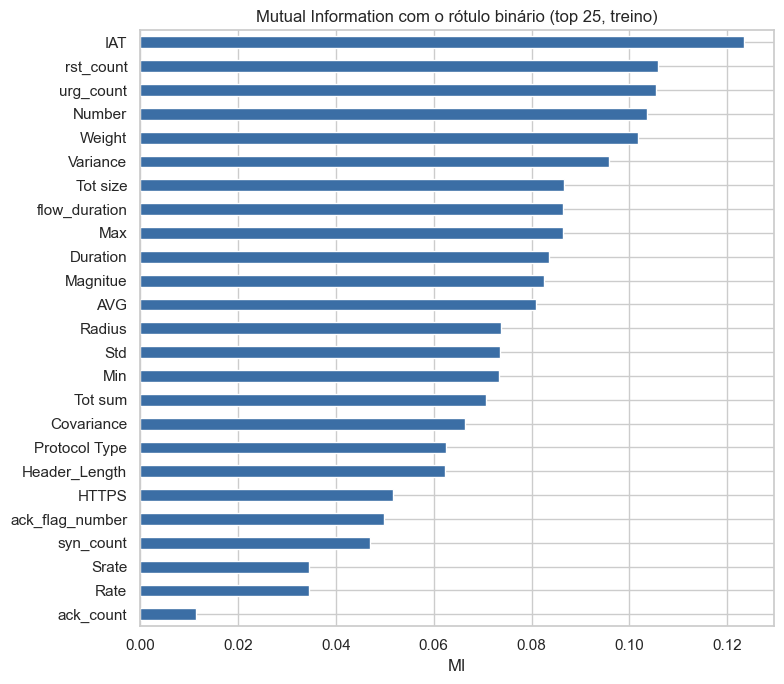

In [ ]:
# ---------- Características efetivamente selecionadas ----------
sel_report = {}
for name, pipe in fitted.items():
    mask = pipe.named_steps["selector"].get_support()
    sel_report[name] = [f for f, m in zip(FEATURE_NAMES, mask) if m]

sel_df = pd.DataFrame({
    "Modelo": list(sel_report),
    "n_features": [len(v) for v in sel_report.values()],
})
display(sel_df)
print("\nCaracterísticas selecionadas (SelectKBest / Mutual Information):")
print(sel_report["RandomForest"])

# Os scores de MI são idênticos entre modelos (mesmo seletor, mesma semente).
mi_scores = pd.Series(
    fitted["RandomForest"].named_steps["selector"].scores_, index=FEATURE_NAMES
).sort_values(ascending=False)
plt.figure(figsize=(8, 7))
mi_scores.head(25).sort_values().plot(kind="barh", color="#3b6ea5")
plt.title("Mutual Information com o rótulo binário (top 25, treino)")
plt.xlabel("MI")
plt.tight_layout()
plt.show()

## 9. Tabela comparativa do baseline

In [16]:
# Ordem intencional: as métricas sensíveis ao desbalanceamento vêm primeiro.
# A Accuracy é reportada por completude, não como critério de comparação.
COLS_MAIN = ["Recall", "Precision", "F1", "PR_AUC", "BalancedAccuracy",
             "MCC", "ROC_AUC", "Accuracy", "TrainTime_s", "InferTime_s"]
print("=== BASELINE — Etapa 1 (classe positiva = Attack) ===")
display(baseline_table[COLS_MAIN].round(4))

print("\n=== Matriz de confusão (contagens) ===")
display(baseline_table[["TN", "FP", "FN", "TP", "FNR_attack", "FPR_normal"]].round(5))

baseline_table.to_csv(ARTIFACTS_DIR / "baseline_resultados.csv")

=== BASELINE — Etapa 1 (classe positiva = Attack) ===


,Recall,Precision,F1,PR_AUC,BalancedAccuracy,MCC,ROC_AUC,Accuracy,TrainTime_s,InferTime_s
Modelo,,,,,,,,,,
DecisionTree,0.9916,1.0000,0.9957,0.9999,0.9954,0.8904,0.9986,0.9918,89.1343,0.9351
RandomForest,0.9962,0.9994,0.9978,1.0000,0.9894,0.9371,0.9995,0.9958,728.2958,3.7033
LinearSVC,0.9684,0.9996,0.9837,0.9997,0.9780,0.7006,0.9918,0.9690,81.7278,1.1131



=== Matriz de confusão (contagens) ===


,TN,FP,FN,TP,FNR_attack,FPR_normal
Modelo,,,,,,
DecisionTree,43804,37,10928,1284241,0.00844,0.00084
RandomForest,43077,764,4907,1290262,0.00379,0.01743
LinearSVC,43303,538,40968,1254201,0.03163,0.01227


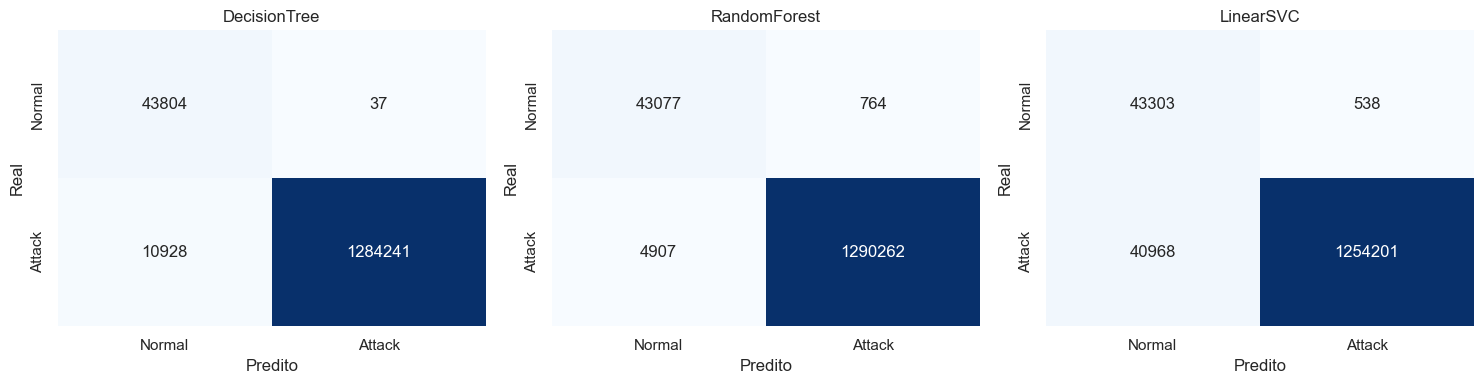

In [17]:
# ---------- Matrizes de confusão ----------
fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 4))
axes = np.atleast_1d(axes)
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
    ax.set_title(name)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "matrizes_confusao.png", dpi=150)
plt.show()

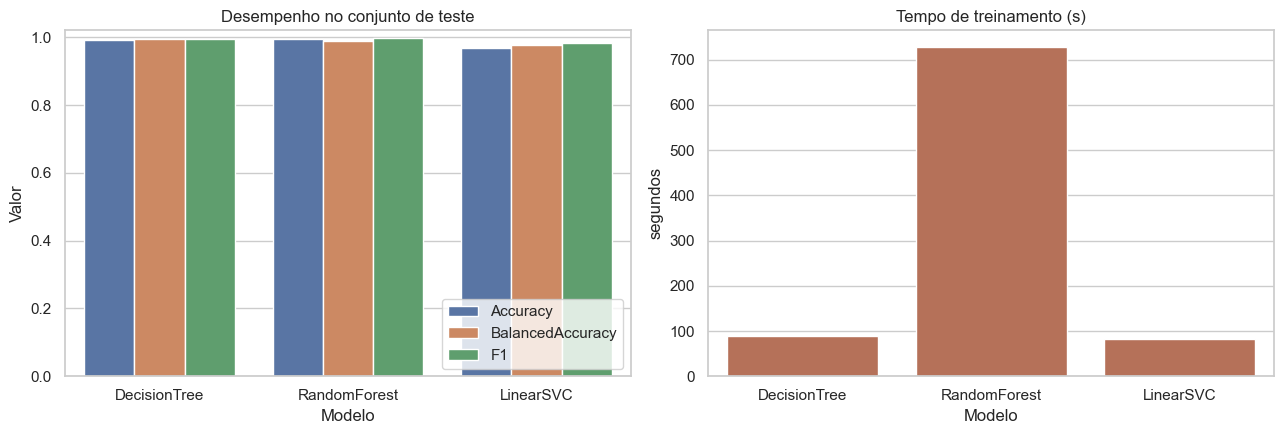

In [18]:
# ---------- Accuracy vs Balanced Accuracy vs F1 ----------
plot_df = baseline_table[["Accuracy", "BalancedAccuracy", "F1"]].reset_index().melt(
    id_vars="Modelo", var_name="Métrica", value_name="Valor")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=plot_df, x="Modelo", y="Valor", hue="Métrica", ax=axes[0])
axes[0].set_ylim(0, 1.02)
axes[0].set_title("Desempenho no conjunto de teste")
axes[0].legend(loc="lower right")

sns.barplot(data=baseline_table.reset_index(), x="Modelo", y="TrainTime_s",
            ax=axes[1], color="#c46a4a")
axes[1].set_title("Tempo de treinamento (s)")
axes[1].set_ylabel("segundos")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "comparacao_baseline.png", dpi=150)
plt.show()

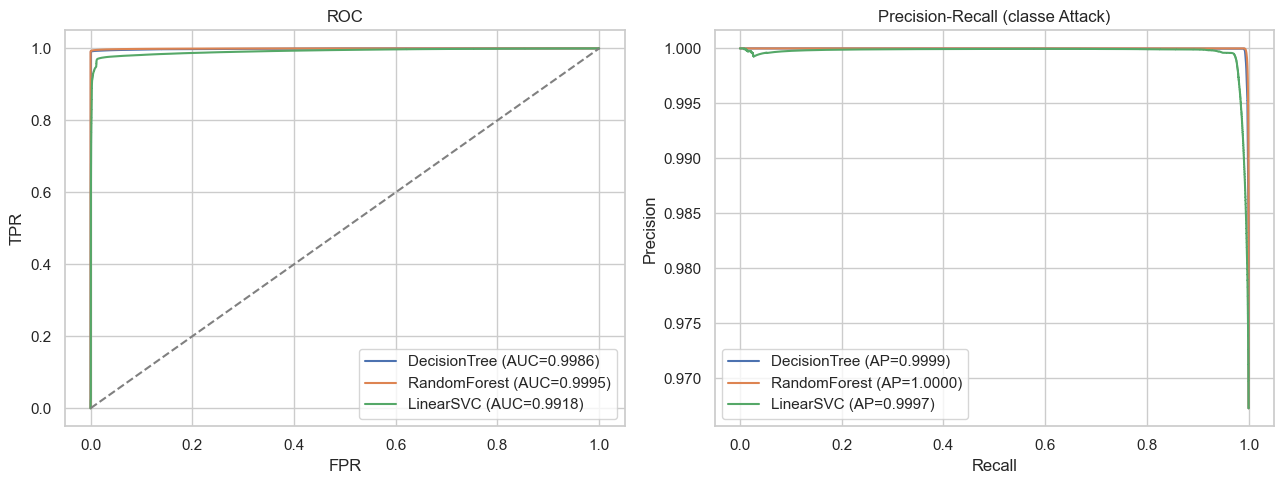

In [19]:
# ---------- Curvas ROC e Precision-Recall ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, pipe in fitted.items():
    s = decision_scores(pipe, X_test)
    if s is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, s)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, s):.4f})")
    prec, rec, _ = precision_recall_curve(y_test, s)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, s):.4f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC"); axes[0].legend()
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall (classe Attack)"); axes[1].legend()
plt.tight_layout()
plt.show()

## 10. Experimento A vs. B — a heurística de remoção por palavra-chave

O notebook de referência descartava colunas cujo **nome** contivesse `flow`,
`ip`, `time`, `id` e outras palavras associadas a identificadores. Aplicada ao
CICIoT2023, a regra elimina `flow_duration` (duração do fluxo) e `IPv` —
ambas medidas de tráfego, nenhuma delas identificador. A decisão de mantê-las
não é declarada, é medida:

- **Experimento A** — espaço de características adotado neste trabalho
  (seleção metodológica: nada removido por nome).
- **Experimento B1** — reprodução parcial: sem `flow_duration`.
- **Experimento B2** — reprodução integral da regra de palavras-chave.

A leitura do resultado é simétrica e ambos os desfechos são publicáveis: se
`A − B` for desprezível, a heurística era inócua e a decisão se justifica pela
ausência de motivo para remover; se for grande, a heurística eliminava
informação legítima de tráfego — e cabe então investigar se essa informação é
uma característica genuína ou um artefato de coleta.

In [20]:
KEYWORD_RULE = ["flow", "ip", "time", "date", "id", "mac", "src", "dst", "host"]
KEYWORD_DROPPED = [c for c in FEATURE_NAMES
                   if any(k in c.lower() for k in KEYWORD_RULE)]
print("Colunas eliminadas pela regra de palavras-chave do notebook de referência:")
print(KEYWORD_DROPPED)

EXPERIMENTS = {
    "A_adotado": FEATURE_NAMES,
    "B1_sem_flow_duration": [c for c in FEATURE_NAMES if c != "flow_duration"],
    "B2_regra_completa": [c for c in FEATURE_NAMES if c not in KEYWORD_DROPPED],
}
for k, v in EXPERIMENTS.items():
    print(f"  {k:<24} {len(v)} características")
if "flow_duration" not in FEATURE_NAMES:
    print("\nAVISO: 'flow_duration' ausente — ajuste os nomes conforme a versão do dataset.")

ab_rows = []
for exp_name, feats in EXPERIMENTS.items():
    for mdl_name, clf in make_models().items():
        pipe = build_pipeline(clf, n_features=len(feats))
        t0 = time.time()
        pipe.fit(X_train[feats], y_train)
        tt = time.time() - t0
        res, _ = evaluate(pipe, X_test[feats], y_test, mdl_name, tt)
        res["Experimento"] = exp_name
        res["n_features_disponiveis"] = len(feats)
        ab_rows.append(res)
        print(f"{exp_name:<24} {mdl_name:<14} recall={res['Recall']:.4f} "
              f"F1={res['F1']:.4f} PR-AUC={res['PR_AUC']:.4f} FN={res['FN']:,}")

ab_df = pd.DataFrame(ab_rows)
AB_METRICS = ["Recall", "Precision", "F1", "PR_AUC", "BalancedAccuracy", "Accuracy"]
print("\n=== Desempenho por espaço de características ===")
display(ab_df.pivot(index="Modelo", columns="Experimento", values=AB_METRICS).round(4))

# ---------- Deltas: A - B (o que a heurística custava) ----------
delta_rows = []
for metric in AB_METRICS:
    piv = ab_df.pivot(index="Modelo", columns="Experimento", values=metric)
    for base in ["B1_sem_flow_duration", "B2_regra_completa"]:
        for modelo in piv.index:
            delta_rows.append({
                "Métrica": metric, "Modelo": modelo, "Comparação": f"A - {base}",
                "A": piv.loc[modelo, "A_adotado"], "B": piv.loc[modelo, base],
                "Δ": piv.loc[modelo, "A_adotado"] - piv.loc[modelo, base],
            })
delta_df = pd.DataFrame(delta_rows)
print("\n=== Δ (A − B): impacto da remoção por palavra-chave ===")
display(delta_df.pivot_table(index=["Métrica", "Modelo"], columns="Comparação",
                             values="Δ").round(5))

ab_df.to_csv(ARTIFACTS_DIR / "experimento_A_vs_B.csv", index=False)
delta_df.to_csv(ARTIFACTS_DIR / "experimento_A_vs_B_deltas.csv", index=False)

Colunas eliminadas pela regra de palavras-chave do notebook de referência:
['flow_duration', 'IPv']
  A_adotado                44 características
  B1_sem_flow_duration     43 características
  B2_regra_completa        42 características
A_adotado                DecisionTree   recall=0.9939 F1=0.9969 PR-AUC=0.9998 FN=7,853
A_adotado                RandomForest   recall=0.9962 F1=0.9978 PR-AUC=1.0000 FN=4,891
A_adotado                LinearSVC      recall=0.9684 F1=0.9837 PR-AUC=0.9997 FN=40,968
B1_sem_flow_duration     DecisionTree   recall=0.9927 F1=0.9962 PR-AUC=0.9998 FN=9,466
B1_sem_flow_duration     RandomForest   recall=0.9949 F1=0.9971 PR-AUC=1.0000 FN=6,614
B1_sem_flow_duration     LinearSVC      recall=0.9700 F1=0.9846 PR-AUC=0.9997 FN=38,866
B2_regra_completa        DecisionTree   recall=0.9927 F1=0.9962 PR-AUC=0.9998 FN=9,466
B2_regra_completa        RandomForest   recall=0.9949 F1=0.9971 PR-AUC=1.0000 FN=6,614
B2_regra_completa        LinearSVC      recall=0.9700 F1=0.9846 

Recall                                        Precision                                               F1                       \
Experimento  A_adotado B1_sem_flow_duration B2_regra_completa A_adotado B1_sem_flow_duration B2_regra_completa A_adotado B1_sem_flow_duration   
Modelo                                                                                                                                          
DecisionTree    0.9939               0.9927            0.9927    0.9998               0.9998            0.9998    0.9969               0.9962   
LinearSVC       0.9684               0.9700            0.9700    0.9996               0.9996            0.9996    0.9837               0.9846   
RandomForest    0.9962               0.9949            0.9949    0.9994               0.9994            0.9994    0.9978               0.9971   

                                  PR_AUC                                        BalancedAccuracy                                         Accuracy  \
Experimento  B2_regra_completa A_adotado B1_sem_flow_duration B2_regra_completa        A_adotado B1_sem_flow_duration B2_regra_completa A_adotado   
Modelo                                                                                                                                              
DecisionTree            0.9962    0.9998               0.9998            0.9998           0.9941               0.9938            0.9938    0.9939   
LinearSVC               0.9846    0.9997               0.9997            0.9997           0.9780               0.9797            0.9797    0.9690   
RandomForest            0.9971    1.0000               1.0000            1.0000           0.9893               0.9888            0.9888    0.9958   

                                                     
Experimento  B1_sem_flow_duration B2_regra_completa  
Modelo                                               
DecisionTree               0.9928            0.9928  
LinearSVC                  0.9706            0.9706  
RandomForest               0.9945            0.9945


=== Δ (A − B): impacto da remoção por palavra-chave ===


Comparação                     A - B1_sem_flow_duration  A - B2_regra_completa
Métrica          Modelo                                                       
Accuracy         DecisionTree                   0.00118                0.00118
                 LinearSVC                     -0.00163               -0.00163
                 RandomForest                   0.00127                0.00127
BalancedAccuracy DecisionTree                   0.00028                0.00028
                 LinearSVC                     -0.00168               -0.00168
                 RandomForest                   0.00040                0.00040
F1               DecisionTree                   0.00062                0.00062
                 LinearSVC                     -0.00087               -0.00087
                 RandomForest                   0.00066                0.00066
PR_AUC           DecisionTree                  -0.00002               -0.00002
                 LinearSVC                     -0.00002               -0.00002
                 RandomForest                   0.00001                0.00001
Precision        DecisionTree                  -0.00002               -0.00002
                 LinearSVC                     -0.00006               -0.00006
                 RandomForest                  -0.00002               -0.00002
Recall           DecisionTree                   0.00125                0.00125
                 LinearSVC                     -0.00162               -0.00162
                 RandomForest                   0.00133                0.00133

## 11. Análise de sensibilidade — número de características (k)

O notebook de referência fixava `k = 40` sobre um espaço de ~45 características,
o que descarta quase nada e torna a seleção praticamente inócua. Adotar `k = 20`
porque "parece melhor" trocaria uma escolha arbitrária por outra. A grade
`K_GRID` mede o compromisso entre desempenho e custo, mantendo todo o resto
idêntico, para que o valor adotado possa ser justificado com evidência.

k=10  DecisionTree   recall=0.9934 F1=0.9965 PR-AUC=0.9997 bal_acc=0.9928 treino=57.9s
k=10  RandomForest   recall=0.9961 F1=0.9977 PR-AUC=1.0000 bal_acc=0.9869 treino=315.8s
k=10  LinearSVC      recall=0.9362 F1=0.9668 PR-AUC=0.9993 bal_acc=0.9613 treino=61.7s
k=20  DecisionTree   recall=0.9939 F1=0.9969 PR-AUC=0.9998 bal_acc=0.9941 treino=75.3s
k=20  RandomForest   recall=0.9962 F1=0.9978 PR-AUC=1.0000 bal_acc=0.9893 treino=385.7s
k=20  LinearSVC      recall=0.9684 F1=0.9837 PR-AUC=0.9997 bal_acc=0.9780 treino=84.7s
k=30  DecisionTree   recall=0.9940 F1=0.9969 PR-AUC=0.9998 bal_acc=0.9945 treino=85.0s
k=30  RandomForest   recall=0.9965 F1=0.9980 PR-AUC=1.0000 bal_acc=0.9907 treino=394.1s
k=30  LinearSVC      recall=0.9652 F1=0.9822 PR-AUC=0.9997 bal_acc=0.9789 treino=125.1s
k=40  DecisionTree   recall=0.9942 F1=0.9970 PR-AUC=0.9998 bal_acc=0.9948 treino=88.9s
k=40  RandomForest   recall=0.9965 F1=0.9980 PR-AUC=1.0000 bal_acc=0.9913 treino=404.3s
k=40  LinearSVC      recall=0.9667 F1=

F1                              PR_AUC                        BalancedAccuracy                         TrainTime_s                       
Modelo DecisionTree LinearSVC RandomForest DecisionTree LinearSVC RandomForest     DecisionTree LinearSVC RandomForest DecisionTree LinearSVC RandomForest
k                                                                                                                                                         
10           0.9965    0.9668       0.9977       0.9997    0.9993          1.0           0.9928    0.9613       0.9869      57.8694   61.7019     315.7941
20           0.9969    0.9837       0.9978       0.9998    0.9997          1.0           0.9941    0.9780       0.9893      75.3332   84.6568     385.6788
30           0.9969    0.9822       0.9980       0.9998    0.9997          1.0           0.9945    0.9789       0.9907      85.0398  125.1427     394.1264
40           0.9970    0.9830       0.9980       0.9998    0.9997          1.0           0.9948    0.9802       0.9913      88.8678  178.1233     404.2834

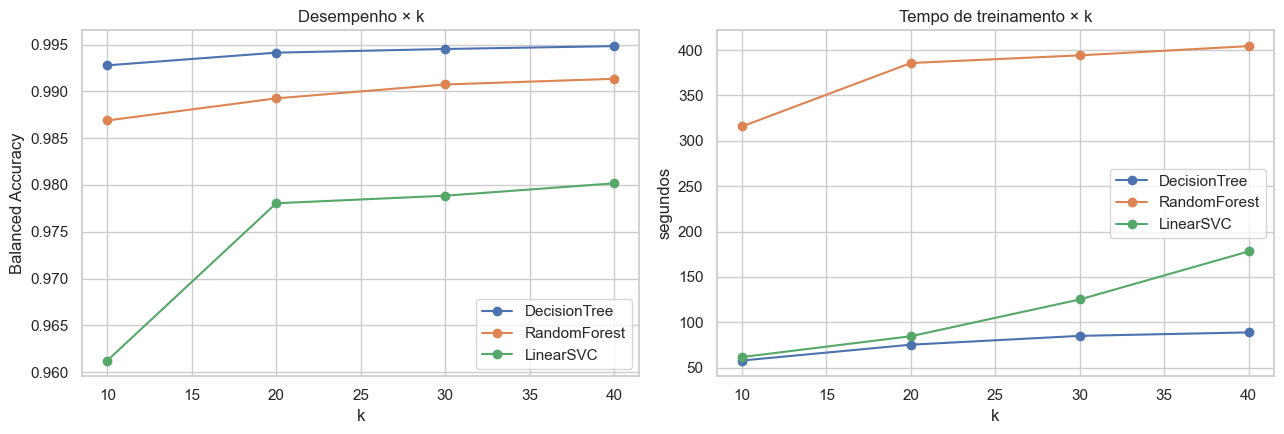

In [21]:
k_rows = []
for k in K_GRID:
    if k > len(FEATURE_NAMES):
        print(f"k={k} excede o número de características ({len(FEATURE_NAMES)}) — ignorado.")
        continue
    for name, clf in make_models().items():
        pipe = build_pipeline(clf, k=k, n_features=len(FEATURE_NAMES))
        t0 = time.time()
        pipe.fit(X_train, y_train)
        tt = time.time() - t0
        res, _ = evaluate(pipe, X_test, y_test, name, tt)
        res["k"] = k
        k_rows.append(res)
        print(f"k={k:<3} {name:<14} recall={res['Recall']:.4f} F1={res['F1']:.4f} "
              f"PR-AUC={res['PR_AUC']:.4f} bal_acc={res['BalancedAccuracy']:.4f} "
              f"treino={tt:.1f}s")

k_df = pd.DataFrame(k_rows)
print("\n=== Sensibilidade ao número de características ===")
display(k_df.pivot(index="k", columns="Modelo",
                   values=["F1", "PR_AUC", "BalancedAccuracy", "TrainTime_s"]).round(4))
k_df.to_csv(ARTIFACTS_DIR / "sensibilidade_k.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name in k_df["Modelo"].unique():
    sub = k_df[k_df["Modelo"] == name].sort_values("k")
    axes[0].plot(sub["k"], sub["BalancedAccuracy"], marker="o", label=name)
    axes[1].plot(sub["k"], sub["TrainTime_s"], marker="o", label=name)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Balanced Accuracy")
axes[0].set_title("Desempenho × k"); axes[0].legend()
axes[1].set_xlabel("k"); axes[1].set_ylabel("segundos")
axes[1].set_title("Tempo de treinamento × k"); axes[1].legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "sensibilidade_k.png", dpi=150)
plt.show()

> Preencher na metodologia com o valor efetivamente adotado, no formato:
> "Adotou-se k = X por apresentar o melhor compromisso entre desempenho
> preditivo e custo computacional, conforme a análise de sensibilidade."
> Se a curva for plana — o que é plausível neste dataset —, esse também é um
> resultado: a tarefa binária não depende criticamente do número de
> características, e o valor menor deve ser preferido pelo custo e pela
> superfície de ataque reduzida na Etapa 2.

## 12. Análise de sensibilidade — split por partição de origem

Reproduz o `GroupShuffleSplit` do notebook de referência para verificar se a
escolha do esquema de divisão altera as conclusões. A comparação só é
informativa **depois** do controle de duplicatas da seção 3.5 — sem isso, a
diferença entre os dois esquemas se confundiria com o efeito das repetições.

A leitura correta não é "estratificado certo, por grupo errado". Se os
resultados forem equivalentes, confirma-se empiricamente que as 169 partições
são intercambiáveis e a escolha do esquema é indiferente. Se o split por grupo
degradar o desempenho de forma consistente, há estrutura por partição que o
split aleatório estava dissolvendo — e isso muda a interpretação do baseline.

In [22]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
gtr, gte = next(gss.split(X_all, y_all, groups=source_file))
Xg_tr, Xg_te = X_all.iloc[gtr], X_all.iloc[gte]
yg_tr, yg_te = y_all[gtr], y_all[gte]
print(f"Split por grupo — treino {Xg_tr.shape}, teste {Xg_te.shape}")
print(f"  %Attack treino={100 * yg_tr.mean():.3f}  |  %Attack teste={100 * yg_te.mean():.3f}")

group_rows = []
for name, clf in make_models().items():
    pipe = build_pipeline(clf, n_features=len(FEATURE_NAMES))
    t0 = time.time()
    pipe.fit(Xg_tr, yg_tr)
    tt = time.time() - t0
    res, _ = evaluate(pipe, Xg_te, yg_te, name, tt)
    group_rows.append(res)

group_table = pd.DataFrame(group_rows).set_index("Modelo")
comp = pd.DataFrame({
    "BalAcc (estratificado)": baseline_table["BalancedAccuracy"],
    "BalAcc (por grupo)": group_table["BalancedAccuracy"],
    "F1 (estratificado)": baseline_table["F1"],
    "F1 (por grupo)": group_table["F1"],
}).round(4)
print("\n=== Sensibilidade ao esquema de divisão ===")
display(comp)

Split por grupo — treino (5314991, 44), teste (1380055, 44)
  %Attack treino=96.721  |  %Attack teste=96.744

=== Sensibilidade ao esquema de divisão ===


,BalAcc (estratificado),BalAcc (por grupo),F1 (estratificado),F1 (por grupo)
Modelo,,,,
DecisionTree,0.9954,0.9944,0.9957,0.9969
RandomForest,0.9894,0.9891,0.9978,0.9978
LinearSVC,0.9780,0.9801,0.9837,0.9850


## 13. Apêndice — KNN (avaliação preliminar, fora dos experimentos principais)

O notebook de referência incluía o KNN entre os modelos comparados. Ele é
avaliado aqui de forma preliminar e **explicitamente excluído** da comparação
principal do TCC, pelo seguinte motivo, que esta seção documenta com números:

O KNN não constrói um modelo compacto — cada predição exige uma busca sobre o
conjunto de treino. Com a amostra de 20% do CICIoT2023, o custo de *inferência*
torna inviáveis os ataques adversariais da Etapa 2, que exigem milhares a
milhões de consultas ao modelo por exemplo perturbado.

Para manter o tempo de execução aceitável, o apêndice usa uma subamostra
estratificada; os números obtidos **não são comparáveis** aos da seção 9 e
servem apenas para evidenciar a ordem de grandeza do custo.

In [23]:
if RUN_KNN_APPENDIX:
    from sklearn.neighbors import KNeighborsClassifier

    N_KNN_TRAIN, N_KNN_TEST = 50_000, 10_000

    i_tr = stratified_subsample_idx(y_train, N_KNN_TRAIN)
    i_te = stratified_subsample_idx(y_test, N_KNN_TEST)

    knn_pipe = build_pipeline(KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
                              n_features=len(FEATURE_NAMES))
    t0 = time.time()
    knn_pipe.fit(X_train.iloc[i_tr], y_train[i_tr])
    tt = time.time() - t0
    knn_res, _ = evaluate(knn_pipe, X_test.iloc[i_te], y_test[i_te], "KNN (subamostra)", tt)

    print(f"KNN — treino {len(i_tr):,} / teste {len(i_te):,}")
    print(f"  Fit: {tt:.1f}s | Inferência: {knn_res['InferTime_s']:.1f}s "
          f"para {len(i_te):,} amostras")
    print(f"  Extrapolação para o teste completo ({len(y_test):,}): "
          f"~{knn_res['InferTime_s'] * len(y_test) / len(i_te) / 60:.1f} min por passada")
    display(pd.DataFrame([knn_res])[COLS_MAIN].round(4))
else:
    print("Apêndice KNN desativado (RUN_KNN_APPENDIX = False). "
          "Ative para gerar as medidas de custo citadas na justificativa.")

Apêndice KNN desativado (RUN_KNN_APPENDIX = False). Ative para gerar as medidas de custo citadas na justificativa.


## 14. Persistência dos artefatos para a Etapa 2

A Etapa 2 (robustez adversarial) precisa dos **mesmos** modelos treinados e do
**mesmo** conjunto de teste. Retreinar produziria um baseline diferente e
invalidaria a comparação antes/depois.

In [24]:
for name, pipe in fitted.items():
    joblib.dump(pipe, ARTIFACTS_DIR / f"modelo_{name}.joblib")

np.savez_compressed(
    ARTIFACTS_DIR / "conjunto_teste.npz",
    X_test=X_test.to_numpy(dtype=np.float32),
    y_test=y_test,
    X_train_sample=X_train.sample(min(50_000, len(X_train)),
                                  random_state=RANDOM_STATE).to_numpy(dtype=np.float32),
)

META = {
    "env": ENV_INFO,
    "label_col": label_col,
    "class_mapping": {"Normal": 0, "Attack": 1},
    "pos_label": POS_LABEL,
    "feature_names": FEATURE_NAMES,
    "selected_features": sel_report,
    "n_total": int(len(y_all)),
    "n_normal": int((y_all == 0).sum()),
    "n_attack": int((y_all == 1).sum()),
    "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
    "duplicate_policy": DUPLICATE_POLICY,
    "conflict_policy": CONFLICT_POLICY,
    "duplicate_diagnostics": dup_report.to_dict(orient="records"),
    "train_test_overlap_frac": float(overlap),
    "load_time_s": LOAD_TIME,
    "total_runtime_s": time.time() - T0_GLOBAL,
}
with open(ARTIFACTS_DIR / "metadados.json", "w") as fh:
    json.dump(META, fh, indent=2)

# Faixas observadas por característica no treino: necessárias na Etapa 2 para
# restringir as perturbações a valores plausíveis de tráfego.
feature_stats = X_train.describe().T[["min", "max", "mean", "std", "50%"]]
feature_stats["is_integer_valued"] = [
    bool(np.allclose(X_train[c].dropna() % 1, 0)) for c in X_train.columns
]
feature_stats.to_csv(ARTIFACTS_DIR / "estatisticas_features_treino.csv")
display(feature_stats.round(3))

print(f"\nArtefatos salvos em: {ARTIFACTS_DIR.resolve()}")
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")
print(f"\nTempo total de execução: {(time.time() - T0_GLOBAL) / 60:.1f} min")

,min,max,mean,std,50%,is_integer_valued
flow_duration,0.000,1.866983e+05,8.089000e+00,3.348870e+02,3.000000e-02,False
Header_Length,0.000,9.872752e+06,1.069582e+05,5.415259e+05,9.416000e+01,False
Protocol Type,0.000,4.700000e+01,1.050200e+01,9.294000e+00,6.000000e+00,False
Duration,0.000,2.550000e+02,6.727100e+01,1.646400e+01,6.400000e+01,False
Rate,0.000,8.388608e+06,8.296790e+03,7.795326e+04,2.021700e+01,False
Srate,0.000,8.388608e+06,8.296790e+03,7.795326e+04,2.021700e+01,False
Drate,0.000,2.971500e+01,0.000000e+00,1.300000e-02,0.000000e+00,False
fin_flag_number,0.000,1.000000e+00,5.200000e-02,2.220000e-01,0.000000e+00,True
syn_flag_number,0.000,1.000000e+00,2.330000e-01,4.230000e-01,0.000000e+00,True
rst_flag_number,0.000,1.000000e+00,5.800000e-02,2.330000e-01,0.000000e+00,True



Artefatos salvos em: C:\Users\mathe\Downloads\artifacts_baseline
  baseline_resultados.csv  (1.0 KB)
  comparacao_baseline.png  (52.7 KB)
  conjunto_teste.npz  (49044.2 KB)
  cv_treino.csv  (0.5 KB)
  estatisticas_features_treino.csv  (3.1 KB)
  experimento_A_vs_B.csv  (2.9 KB)
  experimento_A_vs_B_deltas.csv  (3.8 KB)
  grid_search_resultados.csv  (0.4 KB)
  matrizes_confusao.png  (45.8 KB)
  metadados.json  (3.6 KB)
  modelo_DecisionTree.joblib  (27.4 KB)
  modelo_LinearSVC.joblib  (4.1 KB)
  modelo_RandomForest.joblib  (209344.3 KB)
  resultados_teste_modelos_otimizados.csv  (1.0 KB)
  sensibilidade_k.csv  (3.5 KB)
  sensibilidade_k.png  (98.0 KB)

Tempo total de execução: 100.3 min


## 15. Discussão do baseline

Preencher com os números efetivamente obtidos. Pontos a cobrir:

1. **Desempenho sem ataque.** Qual modelo lidera em Balanced Accuracy e F1 da
   classe Attack — não em Accuracy. Se as diferenças estiverem na terceira casa
   decimal, dizer isso explicitamente em vez de declarar um vencedor.
2. **Desbalanceamento.** Comparar Accuracy e Balanced Accuracy lado a lado; a
   distância entre as duas mede o quanto a Accuracy é inflada pela classe
   majoritária.
3. **Custo computacional.** Tempo de treino e de inferência, e o que isso
   implica para a Etapa 2 (ataques baseados em consultas multiplicam o tempo
   de inferência por milhares).
4. **Divergências em relação ao trabalho de referência.** Causas plausíveis:
   amostragem de 20% com semente distinta; remoção de duplicatas; split
   estratificado em vez de por grupo; manutenção de `flow_duration` e `IPv`;
   `class_weight` na Decision Tree; `k` da seleção de características; versões
   de bibliotecas; hardware.
5. **Limitações.** A amostragem de 20% e a análise restrita às características
   dos CSVs (sem PCAP) delimitam o escopo do que o baseline sustenta.

> Métricas próximas de 1,0 **não** encerram a questão. Elas descrevem o
> desempenho sob a hipótese de que os dados de teste vêm da mesma distribuição
> do treino — hipótese que um adversário viola por construção. É esta a lacuna
> que a Etapa 2 investiga.

---
# Etapa 2 — Projeto dos ataques adversariais (NÃO IMPLEMENTADO)

Esta seção define a metodologia **antes** da implementação, conforme a decisão
metodológica do TCC. Nada aqui é executado neste notebook; a implementação
ocorrerá em um notebook separado que carrega os artefatos da seção 14.

## 16.1 Modelo de ameaça

| Dimensão | Definição adotada |
|---|---|
| **Objetivo do atacante** | Evasão: fazer com que tráfego de ataque (y=1) seja classificado como Normal (y=0) |
| **Direção** | *Targeted* na prática (alvo único: a classe Normal), o que num problema binário coincide com untargeted a partir da classe Attack |
| **Momento** | *Evasion attack* em tempo de inferência. Não há *poisoning*: os modelos já estão treinados e congelados |
| **Conhecimento** | Dois cenários: **white-box** (atacante conhece modelo e parâmetros — limite superior do dano) e **black-box** por consulta (atacante só observa a saída — mais realista) |
| **Capacidade** | O atacante controla o tráfego que ele próprio emite e pode ajustar parâmetros de envio, mas **não** pode editar o registro que o IDS observa nem alterar features derivadas de forma inconsistente |
| **Amostras atacadas** | Apenas as amostras do teste com y=1 **corretamente classificadas** pelo modelo alvo. Perturbar um falso negativo já existente não é evasão |

## 16.2 Restrições de plausibilidade no espaço de características

Este é o ponto que separa um ataque adversarial legítimo de ruído aleatório. As
features do CICIoT2023 não são pixels: elas têm unidade, sinal, domínio e
dependências entre si. As perturbações devem respeitar:

**(a) Particionamento das features por editabilidade** — a ser preenchido a
partir de `estatisticas_features_treino.csv`:

- **Editáveis com custo baixo** — o atacante controla diretamente e alterar
  não o impede de atingir o objetivo: `flow_duration`, `Header_Length`,
  `Rate`/`Srate`, `IAT`, `Tot size`/`Min`/`Max`/`AVG`/`Std`, contagens de
  flags (`syn_count`, `ack_count`, `urg_count`, ...), `Number`.
- **Editáveis com custo alto / semânticas** — alterar degrada o próprio ataque
  (ex.: reduzir `Rate` a ponto de descaracterizar um flood). Devem entrar no
  modelo com um orçamento mais restrito ou ser justificadas caso a caso.
- **Não editáveis** — definidas pelo protocolo escolhido, não pelo atacante:
  indicadores one-hot de protocolo (`TCP`, `UDP`, `ICMP`, `HTTP`, `DNS`,
  `ARP`, ...), `Protocol Type`. Alterá-las significaria executar um ataque
  diferente, não evadir o mesmo ataque.

**(b) Restrições de domínio** — aplicadas por projeção após cada passo:

- Não negatividade: durações, tamanhos, taxas e contagens ≥ 0.
- Integralidade: contagens e flags arredondadas para inteiros.
- Limites de faixa: valores mantidos dentro do intervalo `[min, max]`
  observado no treino (evita exemplos fora do espaço fisicamente realizável).
- Coerência entre features derivadas: `Rate ≈ Number / flow_duration`,
  `AVG`, `Min`, `Max`, `Std` calculados sobre os mesmos pacotes. Recomputar as
  derivadas a partir das primitivas perturbadas em vez de perturbá-las
  independentemente.

**(c) Orçamento de perturbação** — norma L∞ **relativa**, por feature:
`|δ_j| ≤ ε · σ_j(treino)`, com `ε ∈ {0.01, 0.05, 0.1, 0.25, 0.5, 1.0}`.
Normalizar pelo desvio-padrão do treino é necessário porque as features do
CICIoT2023 diferem em várias ordens de grandeza (bytes vs. flags binárias);
uma norma absoluta única seria arbitrária. Reportar também a L0 (quantas
features foram alteradas), que é a medida de esforço mais próxima do que um
atacante real enfrenta.

## 16.3 Métodos de ataque por modelo

Aplicar FGSM/PGD diretamente a árvores é um erro metodológico: não há gradiente.
A escolha do método precisa acompanhar a natureza do modelo.

| Modelo alvo | Cenário | Método proposto | Justificativa |
|---|---|---|---|
| **Linear SVC** | White-box | Perturbação analítica ao longo de `-y·w`, projetada nas restrições | A fronteira é um hiperplano; a perturbação de norma mínima que cruza a fronteira tem forma fechada. Serve de limite inferior do custo de evasão |
| **Decision Tree** | White-box | Busca sobre a estrutura da árvore: para cada folha "Normal", calcular a alteração mínima nas condições do caminho que leva a amostra até ela | Explora a estrutura sem gradiente; produz a perturbação ótima sob L0/L∞ e evidencia quão frágil é uma única árvore |
| **Random Forest** | Black-box | **ZOO / estimativa de gradiente por diferenças finitas** sobre `predict_proba`, ou **Boundary/HopSkipJump** quando só o rótulo estiver disponível | Ensemble não diferenciável; a estimativa numérica do gradiente sobre a probabilidade é a abordagem padrão. Registrar o número de consultas |
| **Todos** | Black-box, *transfer* | Treinar um **surrogate diferenciável** (MLP) sobre pares (entrada, predição do alvo) e gerar exemplos com PGD, transferindo-os ao alvo | Cenário mais realista: o atacante não conhece o modelo. A taxa de transferência é um resultado de interesse próprio |

> **A tabela acima é uma proposta, não um protocolo fechado.** A escolha
> definitiva do algoritmo só deve ser feita depois de (i) executar o baseline
> real, (ii) fixar o modelo de ameaça e (iii) definir exatamente quais
> características são editáveis. Um algoritmo não deve ser adotado por
> funcionar tecnicamente sobre o vetor de features: ele precisa ser compatível
> com as restrições de plausibilidade e com o que o atacante de fato controla.

Complementarmente, incluir um **ataque de referência ingênuo** (ruído gaussiano
de mesma magnitude L∞) como grupo de controle. Ele não é "o ataque": serve para
demonstrar que a degradação observada vem da otimização adversarial e não da
mera perturbação — exatamente a distinção que o TCC precisa sustentar.

## 16.4 Métricas de robustez

Para cada par (modelo, método, ε):

- **Attack Success Rate (evasão)** = fração das amostras Attack corretamente
  classificadas que passaram a ser preditas como Normal. É a métrica central.
- **Degradação absoluta e relativa** de Accuracy, Balanced Accuracy, Recall e
  F1: `(métrica_limpa − métrica_adversarial) / métrica_limpa`.
- **Recall da classe Attack sob ataque** — em IDS, a queda de Recall é o dano.
- **Perturbação média necessária**: L∞ e L0 medianos dos exemplos que
  evadiram com sucesso. Um modelo que só é evadido com perturbações enormes é
  mais robusto que um evadido com ε mínimo, mesmo que ambos cheguem a 100% de
  evasão no limite.
- **Custo do ataque**: número de consultas ao modelo (black-box) e tempo.
- **Curva robustez × ε**: `Recall(Attack)` em função de ε, com os três modelos
  sobrepostos — a figura-síntese do TCC.
- **Taxa de transferência**: exemplos gerados contra o modelo A que também
  evadem o modelo B (matriz 3×3).

## 16.5 Protocolo experimental

1. Carregar os artefatos da seção 14 — **sem retreinar**.
2. Selecionar um subconjunto controlado do teste (ex.: 5.000 amostras Attack
   corretamente classificadas por todos os três modelos), com semente fixa,
   para tornar os ataques computacionalmente viáveis e a comparação pareada.
3. Para cada (modelo, método, ε): gerar os exemplos, **validar as restrições
   de plausibilidade** (verificação automática antes de avaliar) e medir.
4. Consolidar em uma tabela `Modelo × Método × ε → métricas`.
5. Responder às questões de pesquisa: existe relação entre desempenho limpo e
   robustez? O modelo mais preciso é o mais robusto? — a hipótese a testar é
   que **não**, e que a ordenação dos modelos pode inclusive se inverter.

## 16.6 Pontos de atenção

- As restrições de plausibilidade devem ser verificadas por código, não
  assumidas. Um exemplo adversarial com `flow_duration` negativo invalida o
  resultado.
- O ataque opera no **espaço de features original**, não no espaço
  normalizado. O `Pipeline` salvo aplica `imputer → scaler → selector`
  internamente; a perturbação deve ser aplicada antes dele, que é onde o
  atacante real atua.
- Features não selecionadas pelo `SelectKBest` são ignoradas pelo modelo:
  perturbá-las não tem efeito. Isso é um resultado a reportar, não um bug.
- Documentar o número de consultas: um ataque que exige 10⁶ consultas por
  amostra é tecnicamente bem-sucedido e operacionalmente irrelevante.